# SRA Decision Transformer: Routing-Analyse

In dieser Demo verwenden wir SRA als **Decision Transformer (DT)** für verstärkendes Lernen und analysieren die „Gehirnnutzung“, wenn ein Agent verschiedene GridWorld-Aufgaben löst (z. B. Schatzsuche, Flucht).

Hier visualisieren wir zwei Punkte:
1. **Aufgabentrennung**: Die Ausrichtung der Synapsen, die in „Escape“ und „Treasure“ verwendet werden.
2. **Trennung von Wahrnehmung und Aktion**: Wie sich die zugewiesene Synapse abhängig von den Eingabe-Token-Typen ändert: „Zustand“, „Belohnung“ und „Aktion“.

## 1. Umgebungseinrichtung

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install torch matplotlib seaborn

sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')


## 2. Modell und Aufgaben vorbereiten
Definieren Sie ein Modell mit 16 Experten (Synapsen).

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.sra_language_models import MoESRALanguageModel
class MoESRAConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)
from src.sra_gridworld import generate_trajectory, make_dt_batch
from src.sra_experiment import make_optimizer, load_balance_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = MoESRAConfig(
    vocab_size=100,
    d_model=64,
    n_layers=2,
    n_heads=2,
    num_synapses=16, # Prepare 16 experts
    k=2,
    max_seq_len=64
)
model = MoESRALanguageModel(config.vocab_size, config.d_model, config.n_layers, config.num_synapses, config.k, syn_hidden=128, max_seq_len=200, pad_idx=0).to(device)
optimizer = make_optimizer(model, lr=0.005)

Using device: cpu


## 3. Mini-Trainingsschleife
Generieren Sie zufällig Trajektorien für`treasure`und`escape`und trainieren Sie nur 50 Schritte.(Kurz gehalten, damit es bei Colab schnell endet)

In [3]:
print("Training Decision Transformer...")
model.train()

epochs = 150
batch_size = 32
max_steps = 10

for epoch in range(epochs):
    x, y, _ = make_dt_batch(batch_size, max_steps, device)
    
    optimizer.zero_grad()
    outputs, routing_weights = model(x)
    
    # Calculate loss only for action predictions
    loss = F.cross_entropy(outputs.reshape(-1, config.vocab_size), y.reshape(-1), ignore_index=-100)
    
    lb_loss = load_balance_loss(routing_weights) * 0.1
    total_loss = loss + lb_loss
    
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

print("Training finished!")

Training Decision Transformer...


Epoch 50/150 | Loss: 1.2994


Epoch 100/150 | Loss: 0.9660


Epoch 150/150 | Loss: 0.9070
Training finished!


## 4. Routing-Analyse: Synapsennutzung pro Aufgabe
Fassen Sie nach dem Training zusammen und vergleichen Sie, welche Synapsen der Router vorzugsweise für „Treasure“ und „Escape“ verwendet.

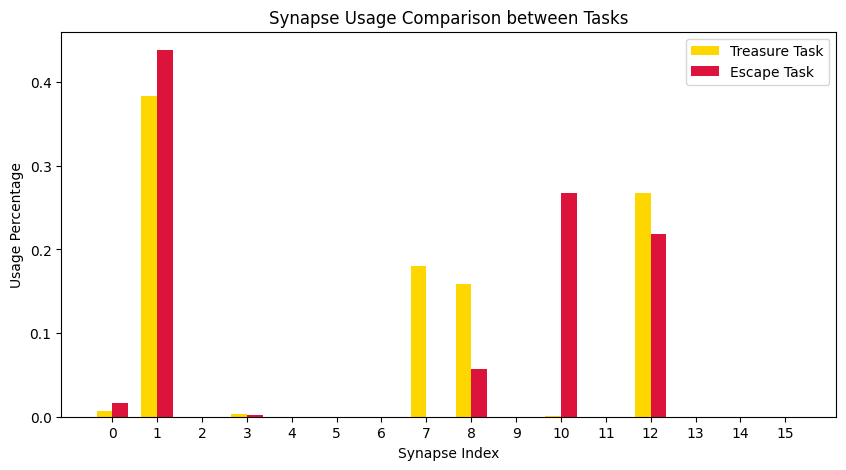

💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).
The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.


In [4]:
def analyze_task_usage(task_type, samples=50):
    model.eval()
    usage_counts = torch.zeros(config.num_synapses, device=device)
    
    with torch.no_grad():
        for _ in range(samples):
            traj = generate_trajectory(task_type, max_steps=5)
            x = torch.tensor([traj], dtype=torch.long).to(device)
            _, routing_weights = model(x)
            
            # Aggregate the indices of synapses used in the final layer's routing
            layer_weights = routing_weights[-1][0]  # [seq_len, n_synapses]
            chosen = layer_weights.argmax(dim=-1)
            usage_counts += torch.bincount(chosen, minlength=config.num_synapses)
            
    usage_pct = (usage_counts / usage_counts.sum()).cpu().numpy()
    return usage_pct

usage_treasure = analyze_task_usage("treasure")
usage_escape = analyze_task_usage("escape")

# Compare using a bar chart
plt.figure(figsize=(10, 5))
x = np.arange(config.num_synapses)
width = 0.35

plt.bar(x - width/2, usage_treasure, width, label='Treasure Task', color='gold')
plt.bar(x + width/2, usage_escape, width, label='Escape Task', color='crimson')

plt.ylabel('Usage Percentage')
plt.xlabel('Synapse Index')
plt.title('Synapse Usage Comparison between Tasks')
plt.xticks(x)
plt.legend()
plt.show()

print("💡 [Insight] You can see that the height of the bars differs depending on the task (= different synapses are used).")
print("The router assigns the 'policy to escape from pursuers' and the 'policy to approach the treasure' to different synapses.")

## 5. Routing-Analyse: Trennung von Wahrnehmung und Aktion (tokenweise Visualisierung)
Überprüfen Sie für eine einzelne „Schatz“-Trajektorie per Heatmap, welcher Synapse jeder Token für Zustand, Belohnung und Aktion zugewiesen wurde.

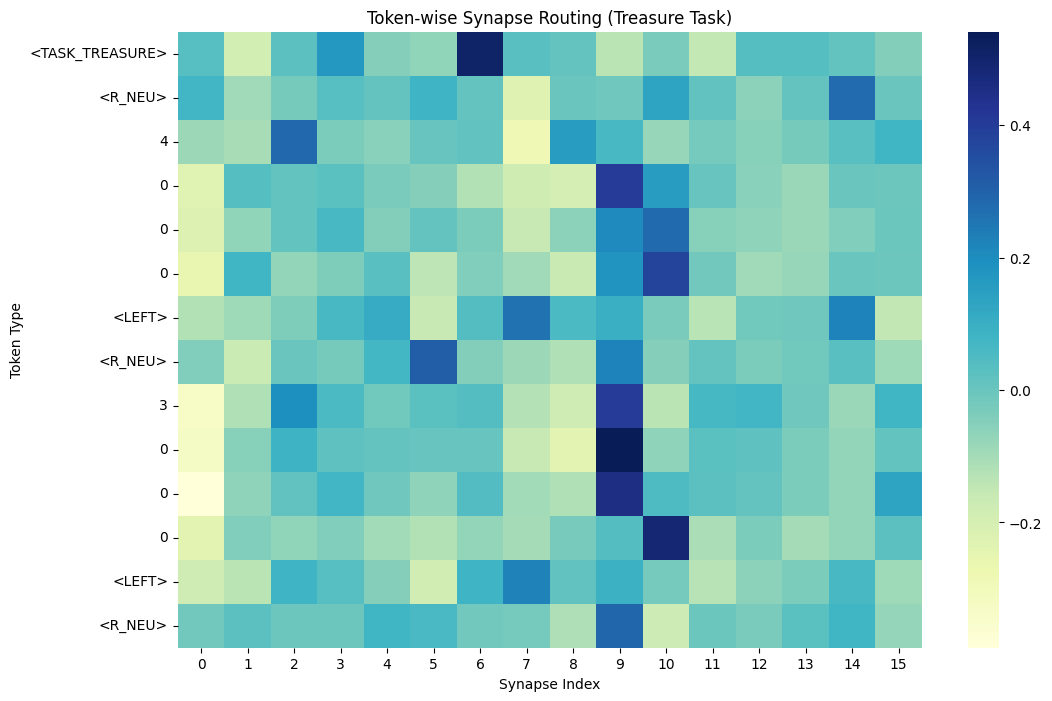

💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',
the darker synapses (horizontal axis) are cleanly separated.


In [5]:
model.eval()
traj = generate_trajectory("treasure", max_steps=2)
x = torch.tensor([traj], dtype=torch.long).to(device)

with torch.no_grad():
    _, routing_weights = model(x)

weights = routing_weights[0][0].cpu().numpy()
from src.constants import ID2TOK
labels = [ID2TOK.get(t, str(t)) for t in traj]

plt.figure(figsize=(12, 8))
sns.heatmap(weights, cmap="YlGnBu", yticklabels=labels, annot=False)
plt.title("Token-wise Synapse Routing (Treasure Task)")
plt.xlabel("Synapse Index")
plt.ylabel("Token Type")
plt.show()

print("💡 [Insight] Looking at the vertical labels, you can observe that for each data type such as 'State', 'Reward', and 'Action',")
print("the darker synapses (horizontal axis) are cleanly separated.")